# Importation

In [1]:
import io
from qubic.lib.Qscene import QubicScene
from qubic.lib.Instrument.Qnoise import QubicTotNoise
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image as IPyImage
from PIL import Image
from pyoperators import (
    MPI,
    BlockColumnOperator,
    BlockDiagonalOperator,
    BlockRowOperator,
    CompositionOperator,
    DenseOperator,
    DiagonalOperator,
    IdentityOperator,
    PackOperator,
    Operator,
    ReshapeOperator,
    flags,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from scipy.optimize import minimize

import qubic
from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

center = np.array([0, -57])
qubic_patch = qubic.lib.Qsamplings.equ2gal(center[0], center[1])

In [4]:
qubic_dict["effective_duration"] = None
qubic_dict["effective_duration150"] = None
qubic_dict["effective_duration220"] = None

# Mixing Matrix

(8, 2)


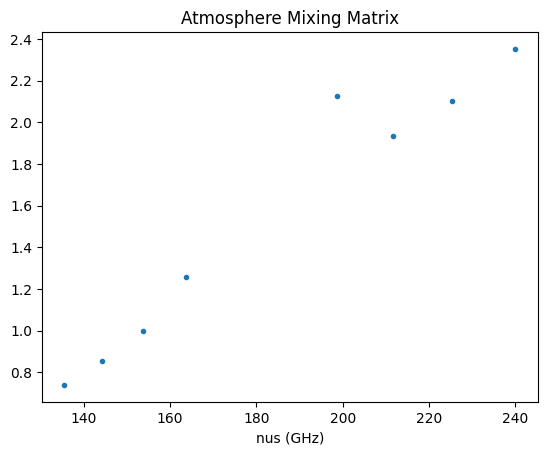

In [5]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix: normalized to reference frequency 150 GHz
mixing_matrix[:, 1] = atm.get_atm_mixing_matrix()
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Scanning Strategy

In [6]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["period"] = 3
qubic_dict["fix_azimuth"]["apply"] = False

### Sweeping pointing
if params["sweeping_pointings"]:
    qubic_dict["random_pointing"] = False
    qubic_dict["sweeping_pointing"] = True

    qubic_dict["angspeed"] = 0.1
    qubic_dict["delta_az"] = 20
    qubic_dict["nsweeps_per_elevation"] = 1
    qubic_dict["duration"] = 1
    # npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
    qubic_dict["period"] = 3600 * qubic_dict["duration"] / params["npointings"]

### Repeat pointing
# qubic_dict["repeat_pointing"] = False

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array([np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)])

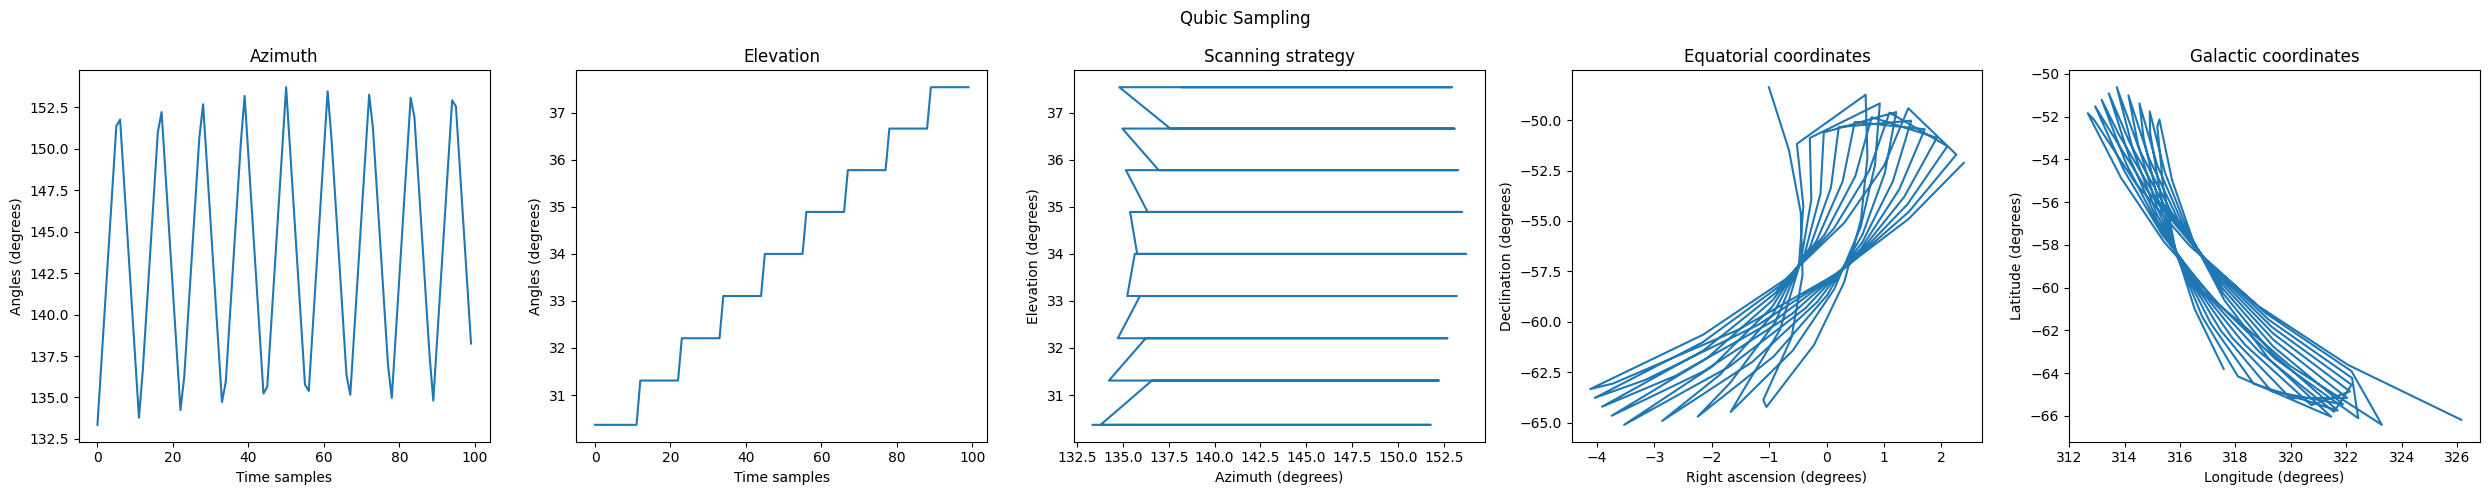

In [7]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot((q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1])
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

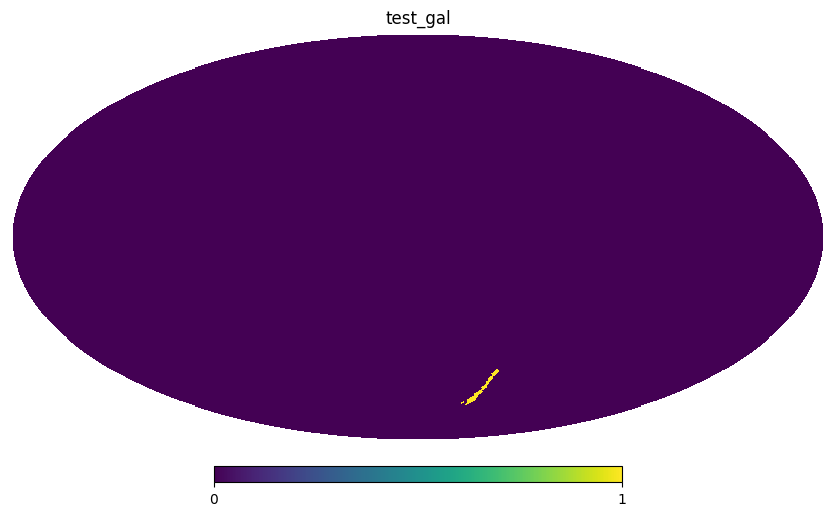

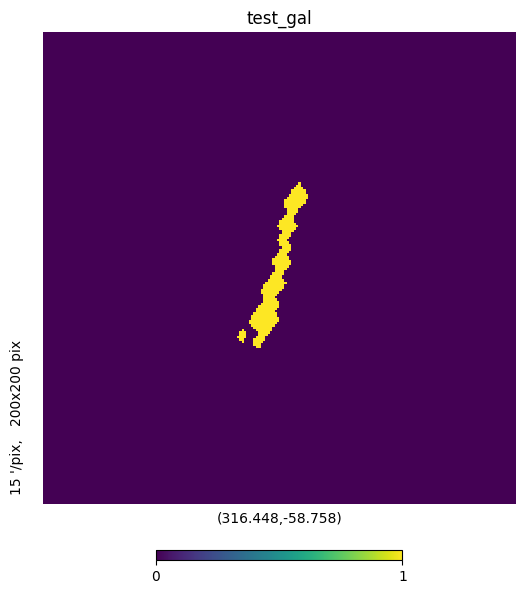

In [8]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Build local sampling

In [9]:
### Define scanning strategy for atm observation
q_sampling_local_rec = QubicSampling(
    q_sampling_gal.index.size,
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local_rec.azimuth = q_sampling_gal.azimuth
q_sampling_local_rec.elevation = q_sampling_gal.elevation
q_sampling_local_rec.pitch = q_sampling_gal.pitch
q_sampling_local_rec.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local_rec.fix_az = True

if params["wind"]:
    wind_class = WindPerturbation(params, q_sampling_gal)
    q_sampling_local = wind_class.get_deviated_qubic_sampling()
else:
    q_sampling_local = q_sampling_local_rec

142.76516566326544 32.49527955194223


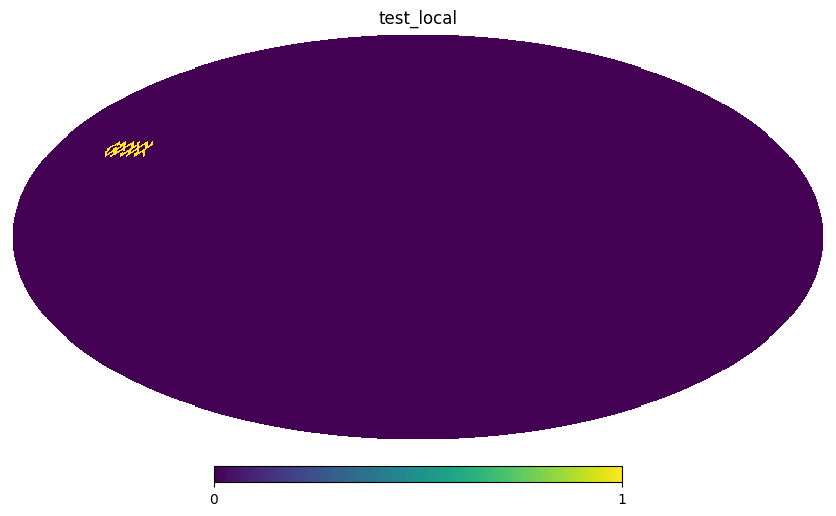

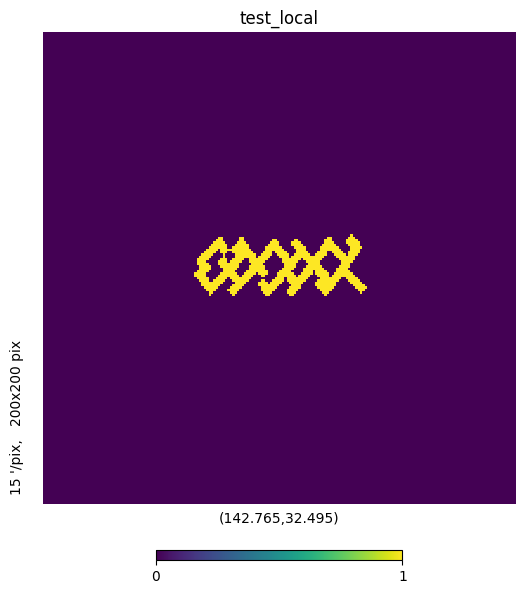

In [10]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

142.76516566326544 32.49527955194223


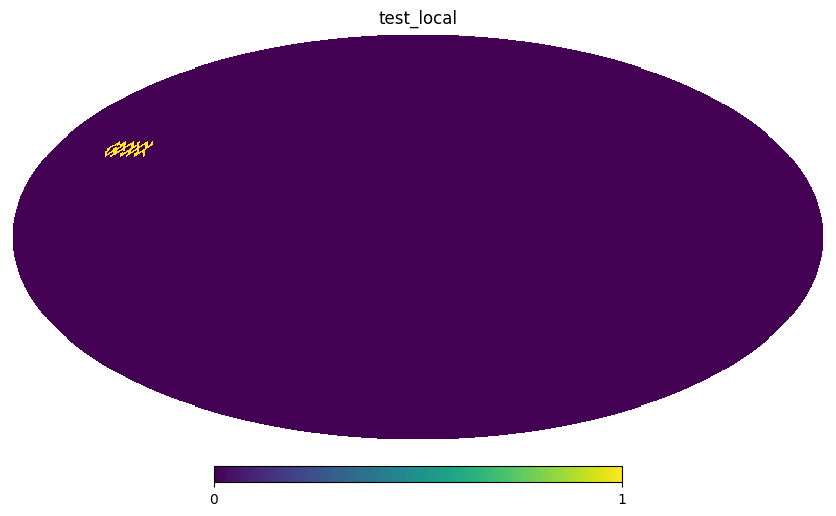

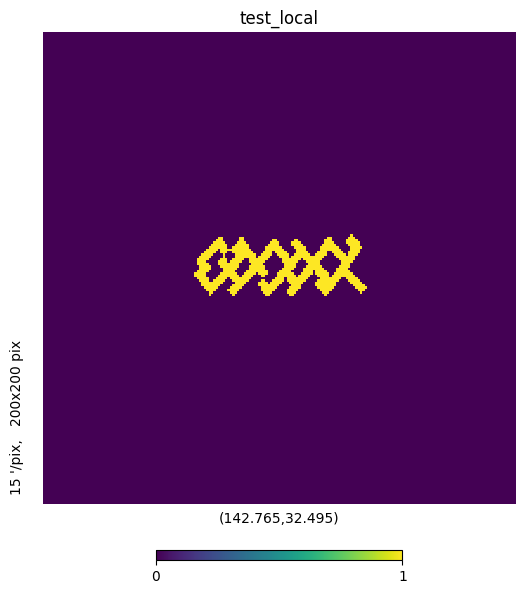

In [11]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

## Build 1 pointing sampling list

In [12]:
print(q_sampling_local)

QubicSampling((100,), 
    index=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 2,
    angle_hwp=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 15. 15. 15. 15. ,
    azimuth=[133.32933716 136.91126422 140.49341432 144.07578797 147.65838568,
    elevation=[30.33840226 30.30974984 30.28109441 30.25243598 30.22377455 30.1,
    equatorial=[[104.46145739 -48.34572504]
 [104.85835236 -51.433514  ]
 [105.1,
    galactic=[[258.32033205 -18.91471262]
 [261.49490471 -19.7048119 ]
 [264.6,
    masked=False,
    pitch=[-10.   -6.4  -2.8   0.8   4.4   8.    8.4   4.8   1.2  -2.4  -6.,
    time=[   0.   36.   72.  108.  144.  180.  216.  252.  288.  324.  360)


In [13]:
q_sampling = []

N_buffer = 10

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicSampling(N_buffer)
    tmp.azimuth = q_sampling_gal.azimuth[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.elevation = q_sampling_gal.elevation[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.pitch = q_sampling_gal.pitch[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.angle_hwp = q_sampling_gal.angle_hwp[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.fix_az = True
    q_sampling.append(tmp)

# Atm

(8, 49152, 3)
(1, 49152, 3)


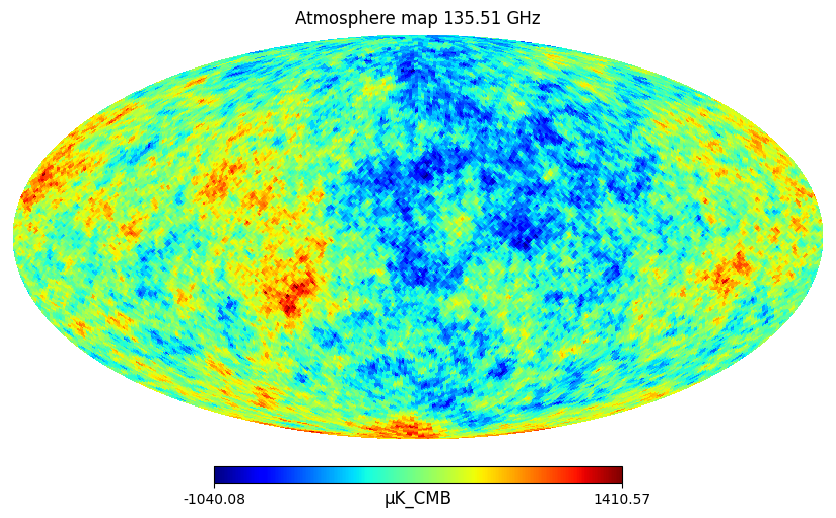

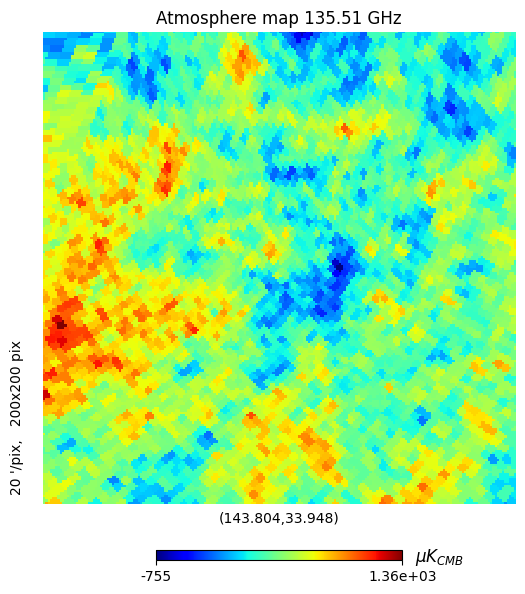

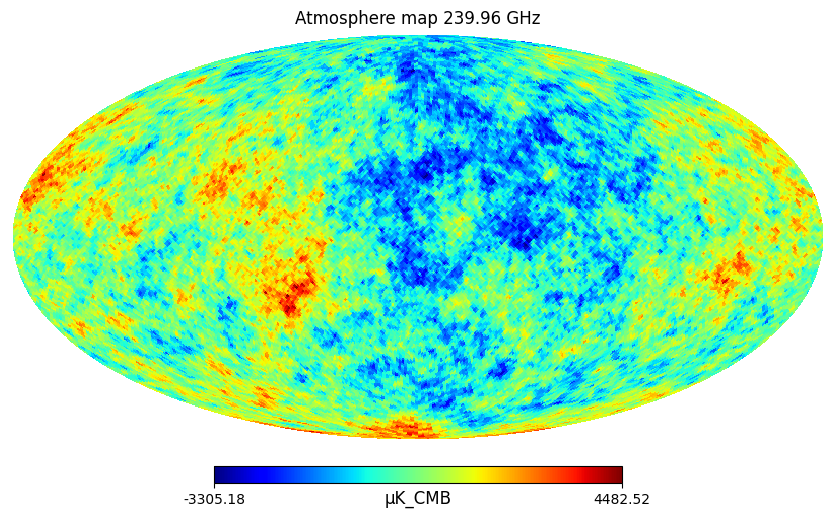

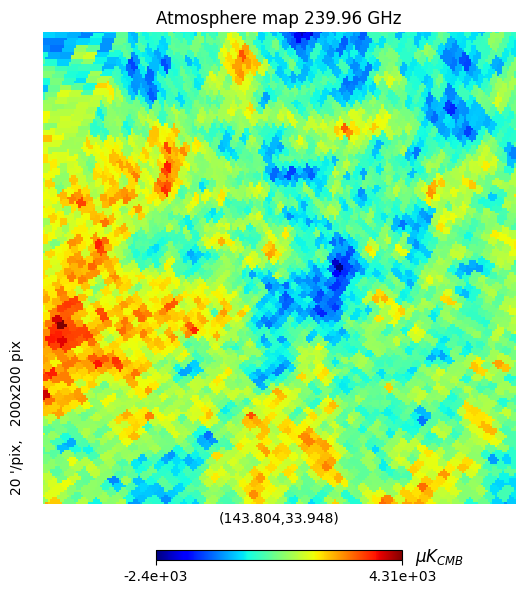

In [14]:
atm_maps = np.ones((params["nsub_in"], hp.nside2npix(params["nside"]), 3)) * atm.get_temp_maps(atm.delta_rho_map)[..., None] / 1e3
# true_maps = atm_maps.mean(axis=0)[None]
true_maps = np.ones((1, hp.nside2npix(params["nside"]), 3)) * atm.get_ref_temp_maps(atm.delta_rho_map)[..., None] / 1e3
atm_maps[..., 1:] *= 0
true_maps[..., 1:] *= 0
print(atm_maps.shape)
print(true_maps.shape)

index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

In [15]:
print(true_maps.shape)

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(1, 49152, 3)


# Wind Operator

In [16]:
@flags.linear
@flags.square
class ShiftOperator(Operator):
    """
    PyOperator wrapping rotate_healpy_map_by_wind.
    Applies a sky rotation defined by a 2D wind vector (wx, wy).
    """

    def __init__(self, wind, dtype=None, **keywords):
        # Always call parent __init__ first in PyOperators subclasses
        Operator.__init__(self, dtype=dtype, **keywords)
        self.wind = np.asarray(wind, dtype=float)  # (wx, wy)

    def direct(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, wind_x, wind_y, verbose=False)
        out[...] = m_rot

    def transpose(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, -wind_x, -wind_y, verbose=False)
        out[...] = m_rot


def get_wind_operator(
    wind,
    Npointings=params["npointings"],
    Nsub=params["nsub_rec"],
    N_buffer=N_buffer,
    nside=params["nside"],
):
    npix = hp.nside2npix(nside)
    shape = (Nsub, npix, 3)
    wind_x, wind_y = wind

    # Convert scalar wind speed to cumulative displacement, matching get_constant_wind
    if np.isscalar(wind_x):
        wind_x = wind_x * np.cumsum(np.ones(Npointings, dtype=float))
    if np.isscalar(wind_y):
        wind_y = wind_y * np.cumsum(np.ones(Npointings, dtype=float))

    chunks = range(0, Npointings, N_buffer)

    tmp = []
    for i in chunks:
        wx_chunk = float(np.mean(wind_x[i : i + N_buffer]))
        wy_chunk = float(np.mean(wind_y[i : i + N_buffer]))

        tmp.append(
            ShiftOperator(
                wind=(wx_chunk, wy_chunk),
                shapein=shape,
                shapeout=shape,
            )
        )

    return BlockColumnOperator(tmp, axisout=0)


# Expected output shape: (n_chunks * nsub_rec, npix, 3)
n_chunks = len(range(0, params["npointings"], N_buffer))
print("Expected output shape:", (n_chunks * params["nsub_rec"], npix, 3))

shift_test = get_wind_operator(wind_class.get_wind(), Npointings=params["npointings"], Nsub=1)

print("shift:", shift_test.shapein, "→", shift_test.shapeout)

Expected output shape: (80, 49152, 3)
shift: (1, 49152, 3) → (10, 49152, 3)


In [17]:
@flags.linear
class PermuteChunksOperator(Operator):
    """
    Reorder TOD from BlockDiagonalOperator's (n_chunks, D, N_buffer) layout
    to the full-acquisition (D, n_chunks, N_buffer) = (D, Npointings) layout.

    BlockDiagonalOperator concatenates per-chunk outputs naively, so chunk 0's
    detectors come before chunk 1's detectors.  The full H_tod operator instead
    produces all time samples for each detector consecutively.  This operator
    corrects that axis swap.

    Direct:    chunked ordering → full ordering   (axes 0↔1 of the 3-D view)
    Transpose: full ordering    → chunked ordering
    """

    def __init__(self, n_chunks, D, N_buffer, **keywords):
        self.n_chunks = n_chunks
        self.D = D
        self.N_buffer = N_buffer
        N = n_chunks * D * N_buffer
        Operator.__init__(self, shapein=(N,), shapeout=(N,), **keywords)

    def direct(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(nc, D, Nb).transpose(1, 0, 2).ravel()

    def transpose(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(D, nc, Nb).transpose(1, 0, 2).ravel()


In [18]:
def create_mollview_gif(maps, duration=100):
    """
    Create a GIF from a sequence of HEALPix maps and display it inline (no file saved).

    Parameters:
    -----------
    maps : list of np.ndarray
        List of HEALPix maps to animate.
    duration : int
        Time between frames in milliseconds.

    Returns:
    --------
    IPython.display.Image object (displays automatically in notebook)
    """
    frames = []
    range = np.max([-np.min(maps[0]), np.max(maps[0])])

    for i, m in enumerate(maps):
        fig = plt.figure(figsize=(10, 6))
        hp.mollview(m, fig=fig, title=f"Frame {i + 1}", unit="K", cmap="jet", min=-range, max=range)

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf))
        plt.close(fig)

    # Save to an in-memory bytes buffer
    gif_buffer = io.BytesIO()
    frames[0].save(
        gif_buffer,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        optimize=True,
        format="GIF",
    )
    gif_buffer.seek(0)

    # Return an IPython Image object (will be displayed automatically)
    return IPyImage(data=gif_buffer.getvalue())

# test = shift_test(true_maps)
# print(test.shape)

# create_mollview_gif(test[..., 0])

# Map-making

## Tod acquisition

Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-

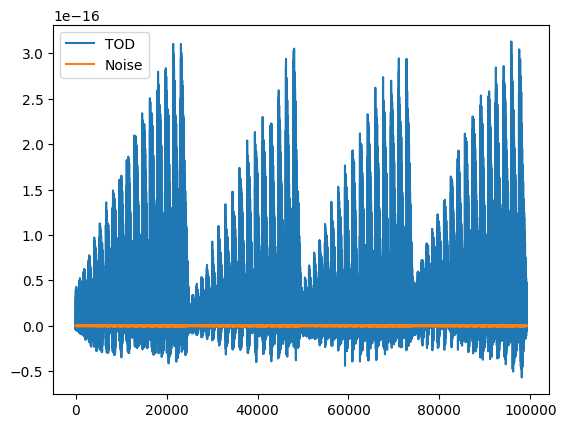

In [19]:
# Build the QUBIC operators with deviated pointing
# H_tod = QubicInstrumentType(
#     atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"], sampling=q_sampling_local
# ).get_operator()

# Build the QUBIC operators with shifting operator
h_tod = []
for ipointing in range(int(params["npointings"] / N_buffer)):
    acq = QubicInstrumentType(
        atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"], sampling=q_sampling[ipointing]
    )
    h_tod.append(acq.get_operator())
    acq.free_comms()


shift_tod = get_wind_operator(
    wind_class.get_wind(),
    Npointings=params["npointings"],
    Nsub=params["nsub_in"],
    nside=params["nside"],
)

print("W : ", shift_tod.shapein, shift_tod.shapeout)

H_tod = BlockDiagonalOperator(h_tod, axisin=0)
print("H_ :", H_tod.shapein, H_tod.shapeout)
print("W  : ", (shift_tod).shapein, (shift_tod).shapeout)

# D = nsub * Ndet (number of "virtual detectors" per time sample)
n_chunks = params["npointings"] // N_buffer
ndet = 992

# Permutation operator: converts BlockDiagonalOperator's (n_chunks, ndet, N_buffer)
# ordering to the full-acquisition (ndet, Npointings) ordering.
Pchunk = PermuteChunksOperator(n_chunks, ndet, N_buffer)
print("Pchunk :", Pchunk.shapein, Pchunk.shapeout)
H = Pchunk * H_tod * shift_tod 
qubic_scene = QubicScene(qubic_dict)
qubic_noise = QubicTotNoise(qubic_dict, q_sampling_gal, qubic_scene).total_noise(params["wdet"], params["wpho150"], params["wpho220"], seed_noise=params["seed"]).ravel()
tod = H(atm_maps).ravel() + qubic_noise
print(tod.shape)

plt.plot(tod, label="TOD")
plt.plot(qubic_noise, label="Noise")
plt.legend()
plt.show()

del h_tod, shift_tod, H_tod, 

## Rec acquisition

In [20]:
Qacq = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local_rec
)

# 1 pointing acq
H_rec = []
invN_rec = []

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicInstrumentType(
        qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling[ipointing]
    )
    H_rec.append(tmp.get_operator())
    invN_rec.append(tmp.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"]))
    tmp.free_comms()

Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
In

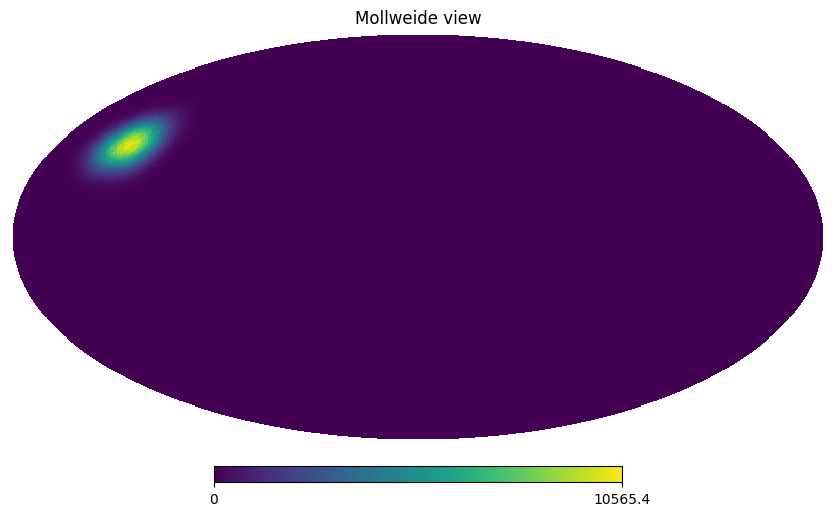

In [21]:
coverage = Qacq.coverage

covnorm = coverage / coverage.max()
seenpix = covnorm > params["coverage_cut"]

hp.mollview(coverage)

# Rec Operator

In [22]:
Amm = DenseOperator(
    mixing_matrix[:, 1, None],
    broadcast="rightward",
    shapein=(1, npix, 3),
    shapeout=(params["nsub_in"], npix, 3),
)
print("A :", Amm.shapein, Amm.shapeout)

wind_rec = (0, 0)
wind_true = params["wind_cst"]
shift = get_wind_operator(
    wind_rec,
    Npointings=params["npointings"],
    Nsub=params["nsub_rec"],
    nside=params["nside"],
)

print("W : ", shift.shapein, shift.shapeout)

A : (1, 49152, 3) (8, 49152, 3)
W :  (8, 49152, 3) (80, 49152, 3)


In [23]:
H_ = BlockDiagonalOperator(H_rec, axisin=0)
print("H_ :", H_.shapein, H_.shapeout)
print("W :", shift.shapein, shift.shapeout)
print("A :", Amm.shapein, Amm.shapeout)
print("W * A : ", (shift * Amm).shapein, (shift * Amm).shapeout)

# D = nsub * Ndet (number of "virtual detectors" per time sample)
n_chunks = params["npointings"] // N_buffer
ndet = 992

# Permutation operator: converts BlockDiagonalOperator's (n_chunks, ndet, N_buffer)
# ordering to the full-acquisition (ndet, Npointings) ordering.
Pchunk = PermuteChunksOperator(n_chunks, ndet, N_buffer)

H = Pchunk * H_ * shift * Amm

# Noise operator: apply Pchunk so it lives in the same (full) ordering as H.
R_chunk = ReshapeOperator(
    (n_chunks * ndet , N_buffer),
    (n_chunks * ndet * N_buffer,),
)
inv_rec = BlockDiagonalOperator(invN_rec, axisout=0)
print("Pchunk :", Pchunk.shapein, Pchunk.shapeout)
print("R_chunk :", R_chunk.shapein, R_chunk.shapeout)
print("inv_rec :", inv_rec.shapein, inv_rec.shapeout)
invN = Pchunk * R_chunk * inv_rec * R_chunk.T * Pchunk.T

print("H :", H.shapein, H.shapeout)
print("invN :", invN.shapein, invN.shapeout)

H_ : (80, 49152, 3) (99200,)
W : (8, 49152, 3) (80, 49152, 3)
A : (1, 49152, 3) (8, 49152, 3)
W * A :  (1, 49152, 3) (80, 49152, 3)
Pchunk : (99200,) (99200,)
R_chunk : (9920, 10) (99200,)
inv_rec : (9920, 10) (9920, 10)
H : (1, 49152, 3) (99200,)
invN : (99200,) (99200,)


In [24]:
# Build PCG
R = ReshapeOperator(tod.shape, H.shapeout)
A = H.T * invN * H
b = H.T * invN * R(tod)
x0 = true_maps  # * 0.0

In [25]:
print("A", A.shapein, A.shapeout)
print("b", b.shape)
print("x0", x0.shape)

A (1, 49152, 3) (1, 49152, 3)
b (1, 49152, 3)
x0 (1, 49152, 3)


In [26]:
def call_pcg(A, b, x0, max_iter=5, M=None):
    algo = PCGAlgorithm(
        A,
        b,
        comm,
        x0=x0,
        tol=1e-12,
        maxiter=max_iter,
        disp=True,
        M=M,
        center=[0, -57],
        reso=15,
        seenpix=seenpix,
        input=true_maps,
    )
    try:
        result = algo.run()
        success = True
        message = "Success"
    except AbnormalStopIteration as e:
        result = algo.finalize()
        success = False
        message = str(e)

    return result


def get_chi2(x, tod):
    wind = get_wind_operator(x)
    tod_sim = Pchunk * H_ * wind * Amm * P(maps_rec)
    res = tod - tod_sim
    return 0.5 * np.dot(res.T, invN(res))


def get_chi2_norm(x, tod, sigma2_eff):
    """Chi2 normalised so that get_chi2_norm(x_best, tod, sigma2_eff) / ndf = 1."""
    return get_chi2(x, tod) / sigma2_eff


def debug_chi2(x0, tod, eps=0.05):
    """Central-difference gradient diagnostic for get_chi2."""
    x0 = np.asarray(x0, dtype=float)
    chi2_0 = get_chi2(x0, tod)
    print(f"  chi2({x0}) = {chi2_0:.6e}")
    grad = np.zeros_like(x0)
    for i in range(len(x0)):
        xp = x0.copy(); xp[i] += eps
        xm = x0.copy(); xm[i] -= eps
        cp = get_chi2(xp, tod)
        cm = get_chi2(xm, tod)
        grad[i] = (cp - cm) / (2 * eps)
        print(f"  chi2(x[{i}]+eps)={cp:.6e}  chi2(x[{i}]-eps)={cm:.6e}  grad[{i}]={grad[i]:.4e}")
    print(f"  gradient = {grad}  (norm={np.linalg.norm(grad):.4e})")
    return chi2_0, grad


def _chi2_grad(x, tod, eps, scale):
    """Central-difference gradient, divided by scale to keep values O(1)."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        xp = x.copy(); xp[i] += eps
        xm = x.copy(); xm[i] -= eps
        g[i] = (get_chi2(xp, tod) - get_chi2(xm, tod)) / (2 * eps * scale)
    return g


def fit_wind(tod, eps=1e-3):
    x0 = np.asarray(wind_rec, dtype=float)

    print(f"  [wind diag] running debug_chi2 at x0={x0} ...")
    chi2_0, grad_0 = debug_chi2(x0, tod, eps=eps)

    scale = np.max([chi2_0, 1.0])

    result = minimize(
        lambda x, t: get_chi2(x, t) / scale,
        x0=x0,
        jac=lambda x, t: _chi2_grad(x, t, eps=eps, scale=scale),
        method="L-BFGS-B",
        args=tod,
        bounds=[(-5, 5), (-5, 5)],
        options={"ftol": 1e-30, "gtol": 1e-10, "maxiter": 100},
    )
    chi2_min = get_chi2(result.x, tod)
    ndf = tod.size - 2
    sigma2_eff = chi2_min / ndf
    print(f"  [wind diag] optimizer: success={result.success}, nfev={result.nfev}, "
          f"x={result.x}, chi2_min={chi2_min:.4e}, chi2_min/ndf={chi2_min/ndf:.4e}, msg={result.message}")
    return result.x, sigma2_eff


# Run Map-Making

In [27]:
# Fix CMB Intensity + Atm Polarisation
mask = np.ones(true_maps.shape)  # Mask for 2 components : CMB & Atm
print(mask.shape)
if params["cmb"] and not params["atm"]:
    mask[..., 0] = 0  # CMB Intensity
elif params["cmb"] and params["atm"]:
    mask[0, :, 0] = 0
    mask[1, :, [1, 2]] = 0  # Atm Polarisation
elif not params["cmb"] and params["atm"]:
    mask[..., [1, 2]] = 0
if params["fix_maps"]:
    P = PackOperator(mask).T  # Build Mask Operator
else:
    P = IdentityOperator()
x_masked = true_maps * (1 - mask)
print("P : ", P.shapein, P.shapeout)

# Start from uniform mixing-matrix (= 1)
mixing_matrix_rec = np.ones_like(mixing_matrix)
wind_op = get_wind_operator(wind_rec)

# Preconditioner
M = None

(1, 49152, 3)
P :  (49152,) (1, 49152, 3)


Chi2 at true wind: 6.4348e+03
Chi2 per degree of freedom at true wind: 6.4868e-02
Residual norm at true wind: 3.7933e-17


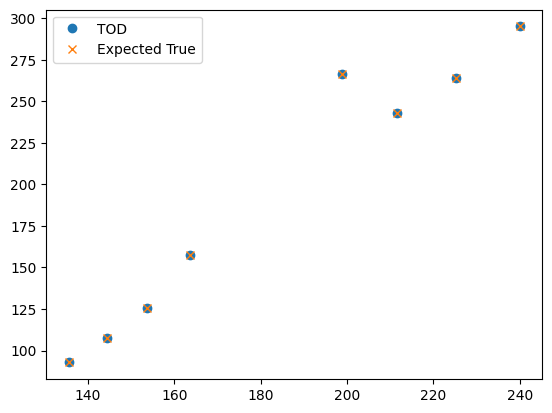

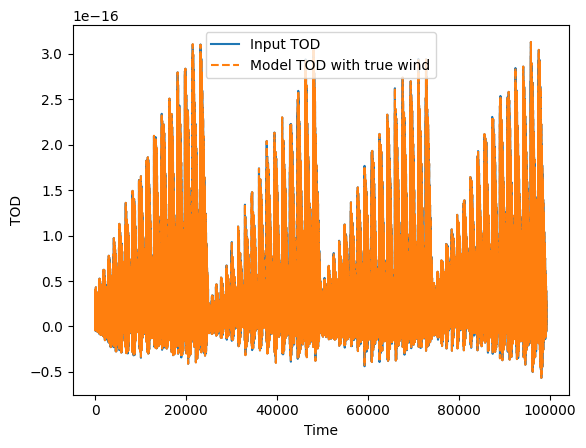

In [28]:
maps_rec = P.T(true_maps) 
wind = get_wind_operator(wind_true)
tod_true = Pchunk * H_ * wind * Amm * true_maps
chi2_true = get_chi2(wind_true, tod)
print(f"Chi2 at true wind: {chi2_true:.4e}")
print(f"Chi2 per degree of freedom at true wind: {chi2_true / (tod.size - 2):.4e}")
print(f"Residual norm at true wind: {np.linalg.norm(tod - tod_true):.4e}")

plt.plot(atm.frequencies, (atm_maps[..., 0]).mean(axis=1), 'o', label="TOD")
plt.plot(atm.frequencies, (mixing_matrix[:, 1][:, None] * true_maps[..., 0]).mean(axis=1), 'x', label="Expected True")
plt.legend()
plt.show()

plt.plot(tod, label="Input TOD")
plt.plot(tod_true, "--", label="Model TOD with true wind")
plt.xlabel("Time")
plt.ylabel("TOD")
plt.legend()
plt.show()

In [ ]:
# Run PCG
convergence = []
wind_iter = [wind_rec]
maps_rec = P.T(true_maps) * 0
print(maps_rec.shape)

for iloop in range(params["n_loop"]):
    print("=====================================")
    print("Iteration : ", iloop)

    print("-------------------------------------")
    print("Fit Maps :")
    print("-------------------------------------")
    H = Pchunk * H_ * wind_op * Amm
    A = P.T * H.T * invN * H * P
    b = P.T * H.T * invN * (tod - H(x_masked))

    if params["iterative_iter"]:
        n_iter = iloop
    else:
        n_iter = params["n_iter"]

    result = call_pcg(A, b, maps_rec, max_iter=n_iter, M=M)
    convergence.append(result["convergence"])
    output = result["x"].copy()
    print("Previous Maps: ", maps_rec.mean(axis=0))

    if params["fix_maps"]:
        if params["cmb"] and params["atm"]:
            maps_rec[0, :, 1:] = output[: npix * 2].reshape(npix, 2)
            maps_rec[1, :, 0] = output[npix * 2 :]
        elif params["cmb"] and not params["atm"]:
            maps_rec[:, 1:] = output[: npix * 2].reshape(npix, 2)
        elif not params["cmb"] and params["atm"]:
            maps_rec = output
    else:
        maps_rec = output

    print("Next Maps: ", maps_rec.mean(axis=0))
    print("Residual Maps: ", (P.T(true_maps)  - maps_rec)[seenpix].mean(axis=0))


    if params["fit_wind"]:
        print("-------------------------------------")
        print("Fit Wind :")
        print("-------------------------------------")
        print("Previous wind: ", wind_rec)
        wind_rec, sigma2_eff = fit_wind(tod)
        wind_iter.append(wind_rec)
        wind_op = get_wind_operator(wind_rec)
        print("Next wind: ", wind_rec)
        if hasattr(wind_true, '__len__'):
            print("Residual wind: ", np.array(wind_true) - np.array(wind_rec))
        
print("=====================================")
print("End of the loop !")    
print("=====================================")
            
# if params["fix_maps"]:
#     print("-------------------------------------")
#     print("Fit Maps after loop:")
#     print("-------------------------------------")
#     H = Pchunk * H_ * wind_op * Amm
#     A = P.T * H.T * invN * H * P
#     b = P.T * H.T * invN * (tod - H(x_masked))

#     result = call_pcg(A, b, maps_rec, max_iter=300, M=M)
#     convergence.append(result["convergence"])
#     output = result["x"].copy()
#     print("Previous Maps: ", maps_rec.mean(axis=0))

#     if params["fix_maps"]:
#         if params["cmb"] and params["atm"]:
#             maps_rec[0, :, 1:] = output[: npix * 2].reshape(npix, 2)
#             maps_rec[1, :, 0] = output[npix * 2 :]
#         elif params["cmb"] and not params["atm"]:
#             maps_rec[:, 1:] = output[: npix * 2].reshape(npix, 2)
#         elif not params["cmb"] and params["atm"]:
#             maps_rec = output
#     else:
#         maps_rec = output

#     print("Next Maps: ", maps_rec.mean(axis=0))
#     print("Residual Maps: ", (P.T(true_maps)  - maps_rec)[seenpix].mean(axis=0))

(49152,)
Iteration :  0
-------------------------------------
Fit Maps :
-------------------------------------
 Iter     Tol      time
   1: 3.1090e-01 0.13650 [0. 0. 0.]
   2: 8.8297e-02 0.13634 [0. 0. 0.]
   3: 5.5581e-02 0.13461 [0. 0. 0.]
   4: 2.6994e-02 0.13358 [0. 0. 0.]
   5: 3.5431e-02 0.13479 [0. 0. 0.]
   6: 2.1026e-02 0.13638 [0. 0. 0.]
   7: 2.1982e-02 0.13902 [0. 0. 0.]
   8: 1.6803e-02 0.14530 [0. 0. 0.]
   9: 1.2832e-02 0.13794 [0. 0. 0.]
  10: 9.9206e-03 0.13556 [0. 0. 0.]
  11: 8.7349e-03 0.13525 [0. 0. 0.]
  12: 1.1208e-02 0.14541 [0. 0. 0.]
  13: 1.0081e-02 0.13510 [0. 0. 0.]
  14: 5.5941e-03 0.13292 [0. 0. 0.]
  15: 5.9817e-03 0.13646 [0. 0. 0.]
  16: 5.6589e-03 0.13715 [0. 0. 0.]
  17: 4.3928e-03 0.13558 [0. 0. 0.]
  18: 6.1255e-03 0.14752 [0. 0. 0.]
  19: 5.1125e-03 0.13948 [0. 0. 0.]
  20: 4.5656e-03 0.14271 [0. 0. 0.]
Previous Maps:  0.0
Next Maps:  6.714890542793525
Residual Maps:  -15.923027170968968
-------------------------------------
Fit Wind :
----------

-2.3612180886519583e-20
1.4303815509978522e-19


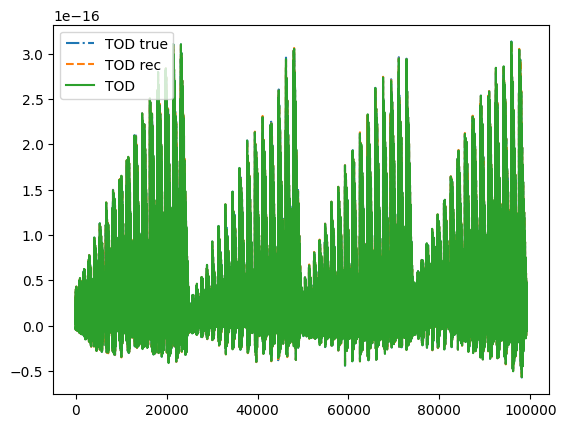

In [30]:
maps_rec_ = P(maps_rec)
plt.plot(H(true_maps),"-.", label="TOD true")
plt.plot(H(maps_rec_), "--", label="TOD rec")
plt.plot(tod, label="TOD")
plt.legend()

print(np.mean(H(maps_rec_) - tod))
print(np.mean(H(true_maps) - tod))

# Convergence & Plot

In [1]:
plt.plot(convergence[:-1])

NameError: name 'plt' is not defined

Text(0, 0.5, 'Convergence')

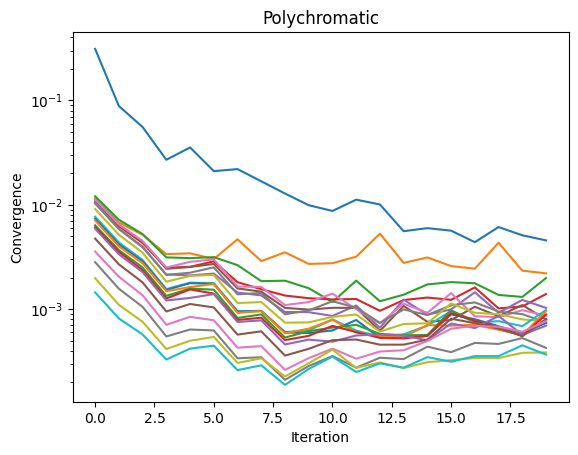

In [41]:
for conv in convergence[:-1]:
    plt.plot(conv)
    
# plt.plot(convergence[-1], label="Final PCG convergence")
plt.title("Polychromatic")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Convergence")

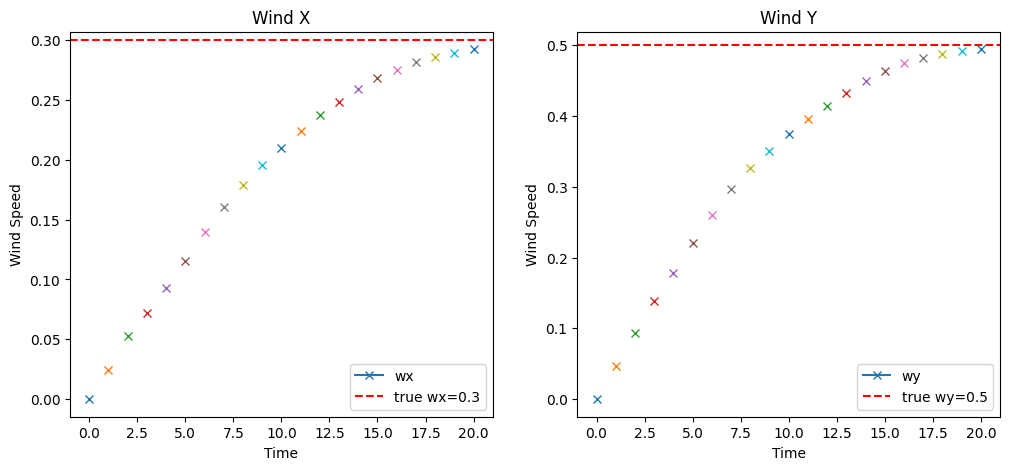

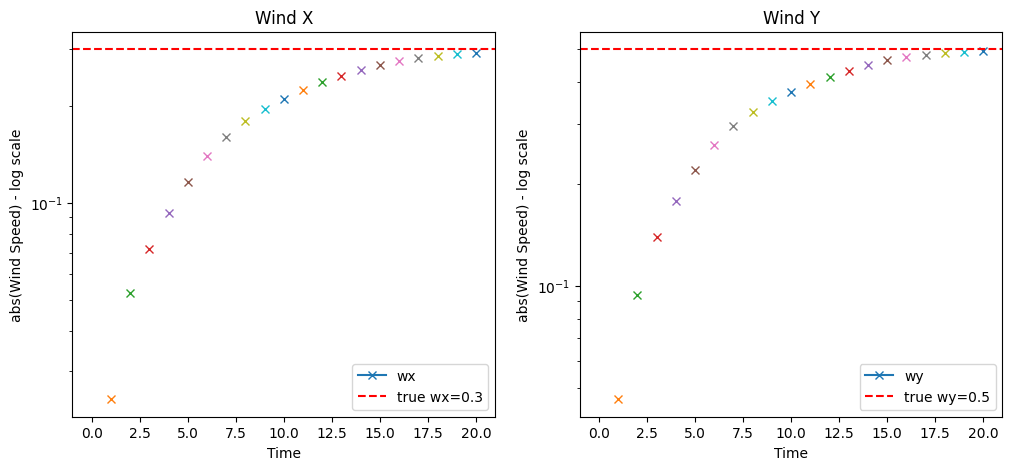

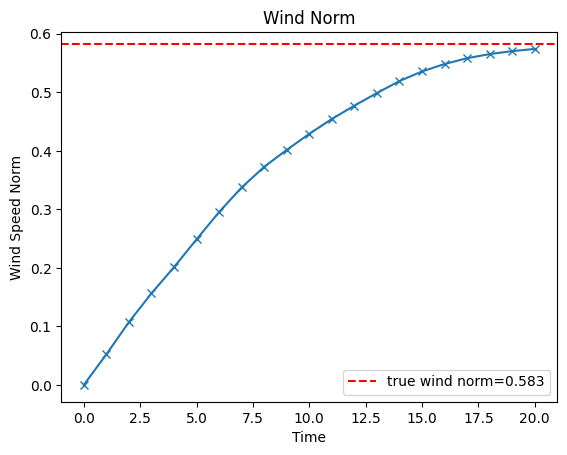

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,iwind in enumerate(wind_iter):
    ax[0].plot(i, iwind[0], "x-", label="wx" if i == 0 else "")
    ax[1].plot(i, iwind[1], "x-", label="wy" if i == 0 else "")

ax[0].axhline(params["wind_cst"][0], color="r", ls="--", label=f"true wx={params['wind_cst'][0]}")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Wind Speed")
ax[0].set_title("Wind X")
ax[0].legend()
ax[1].axhline(params["wind_cst"][1], color="r", ls="--", label=f"true wy={params['wind_cst'][1]}")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Wind Speed")
ax[1].set_title("Wind Y")
ax[1].legend()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,iwind in enumerate(wind_iter):
    ax[0].plot(i, np.abs(iwind[0]), "x-", label="wx" if i == 0 else "")
    ax[1].plot(i, np.abs(iwind[1]), "x-", label="wy" if i == 0 else "")

ax[0].axhline(np.abs(params["wind_cst"][0]), color="r", ls="--", label=f"true wx={np.abs(params['wind_cst'][0])}")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("abs(Wind Speed) - log scale")
ax[0].set_title("Wind X")
ax[0].legend()
ax[0].set_yscale("log")
ax[1].axhline(np.abs(params["wind_cst"][1]), color="r", ls="--", label=f"true wy={np.abs(params['wind_cst'][1])}")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("abs(Wind Speed) - log scale")
ax[1].set_title("Wind Y")
ax[1].legend()
ax[1].set_yscale("log")
plt.show()

plt.figure()
norm_true = np.linalg.norm(wind_true)
norm_iter = [np.linalg.norm(w) for w in wind_iter]
plt.plot(norm_iter, "x-")
plt.axhline(norm_true, color="r", ls="--", label=f"true wind norm={norm_true:.3f}")
plt.xlabel("Time")
plt.ylabel("Wind Speed Norm")
plt.title("Wind Norm")
plt.legend()
plt.show()

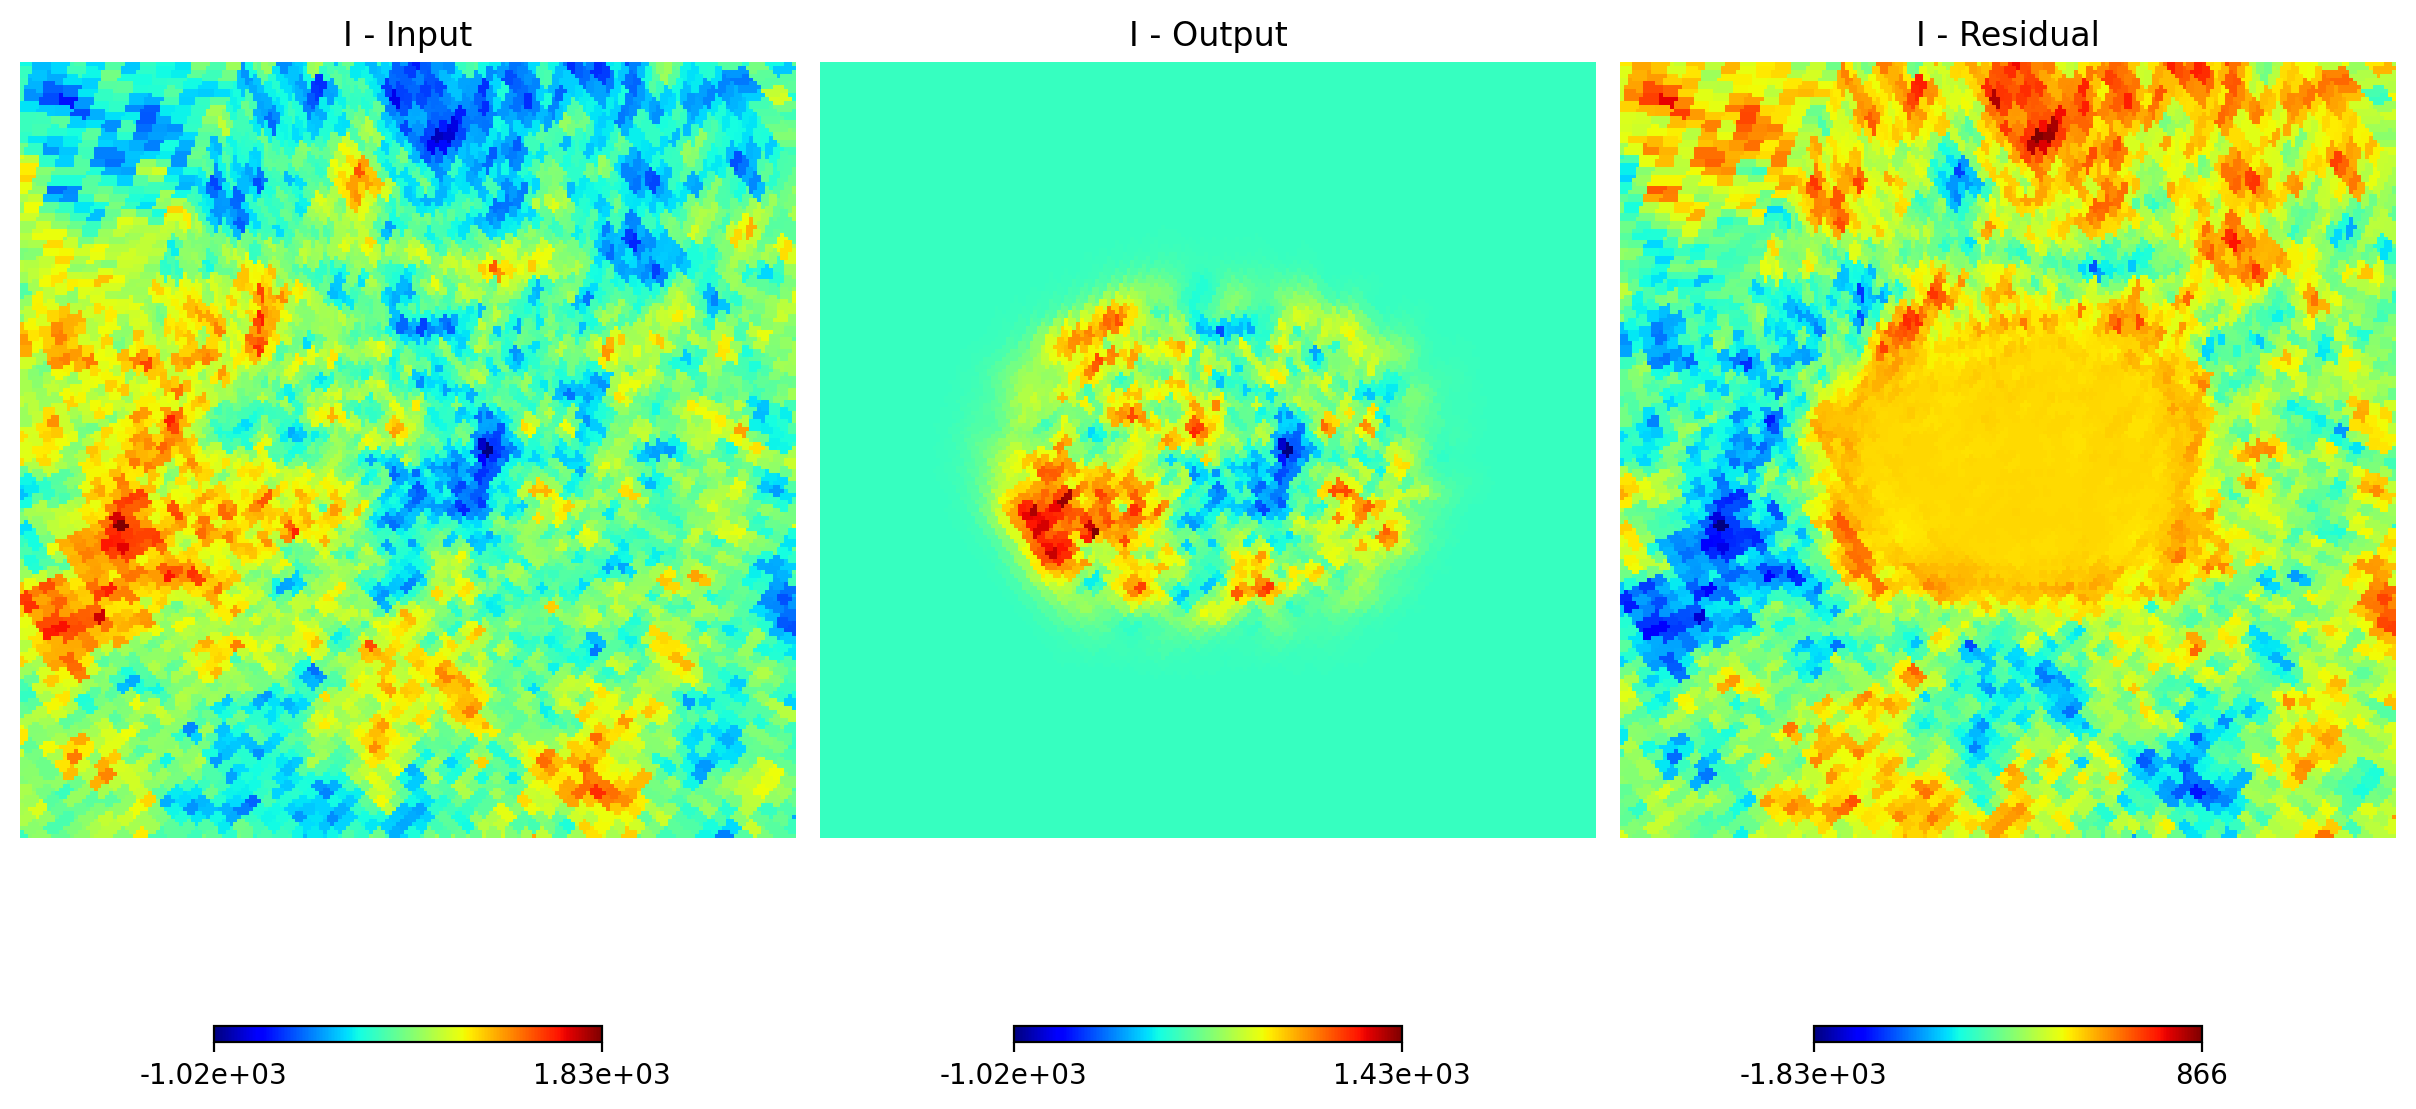

In [43]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
# true_maps[:, ~seenpix, :] = hp.UNSEEN
# output['x'][:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(maps_rec_.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

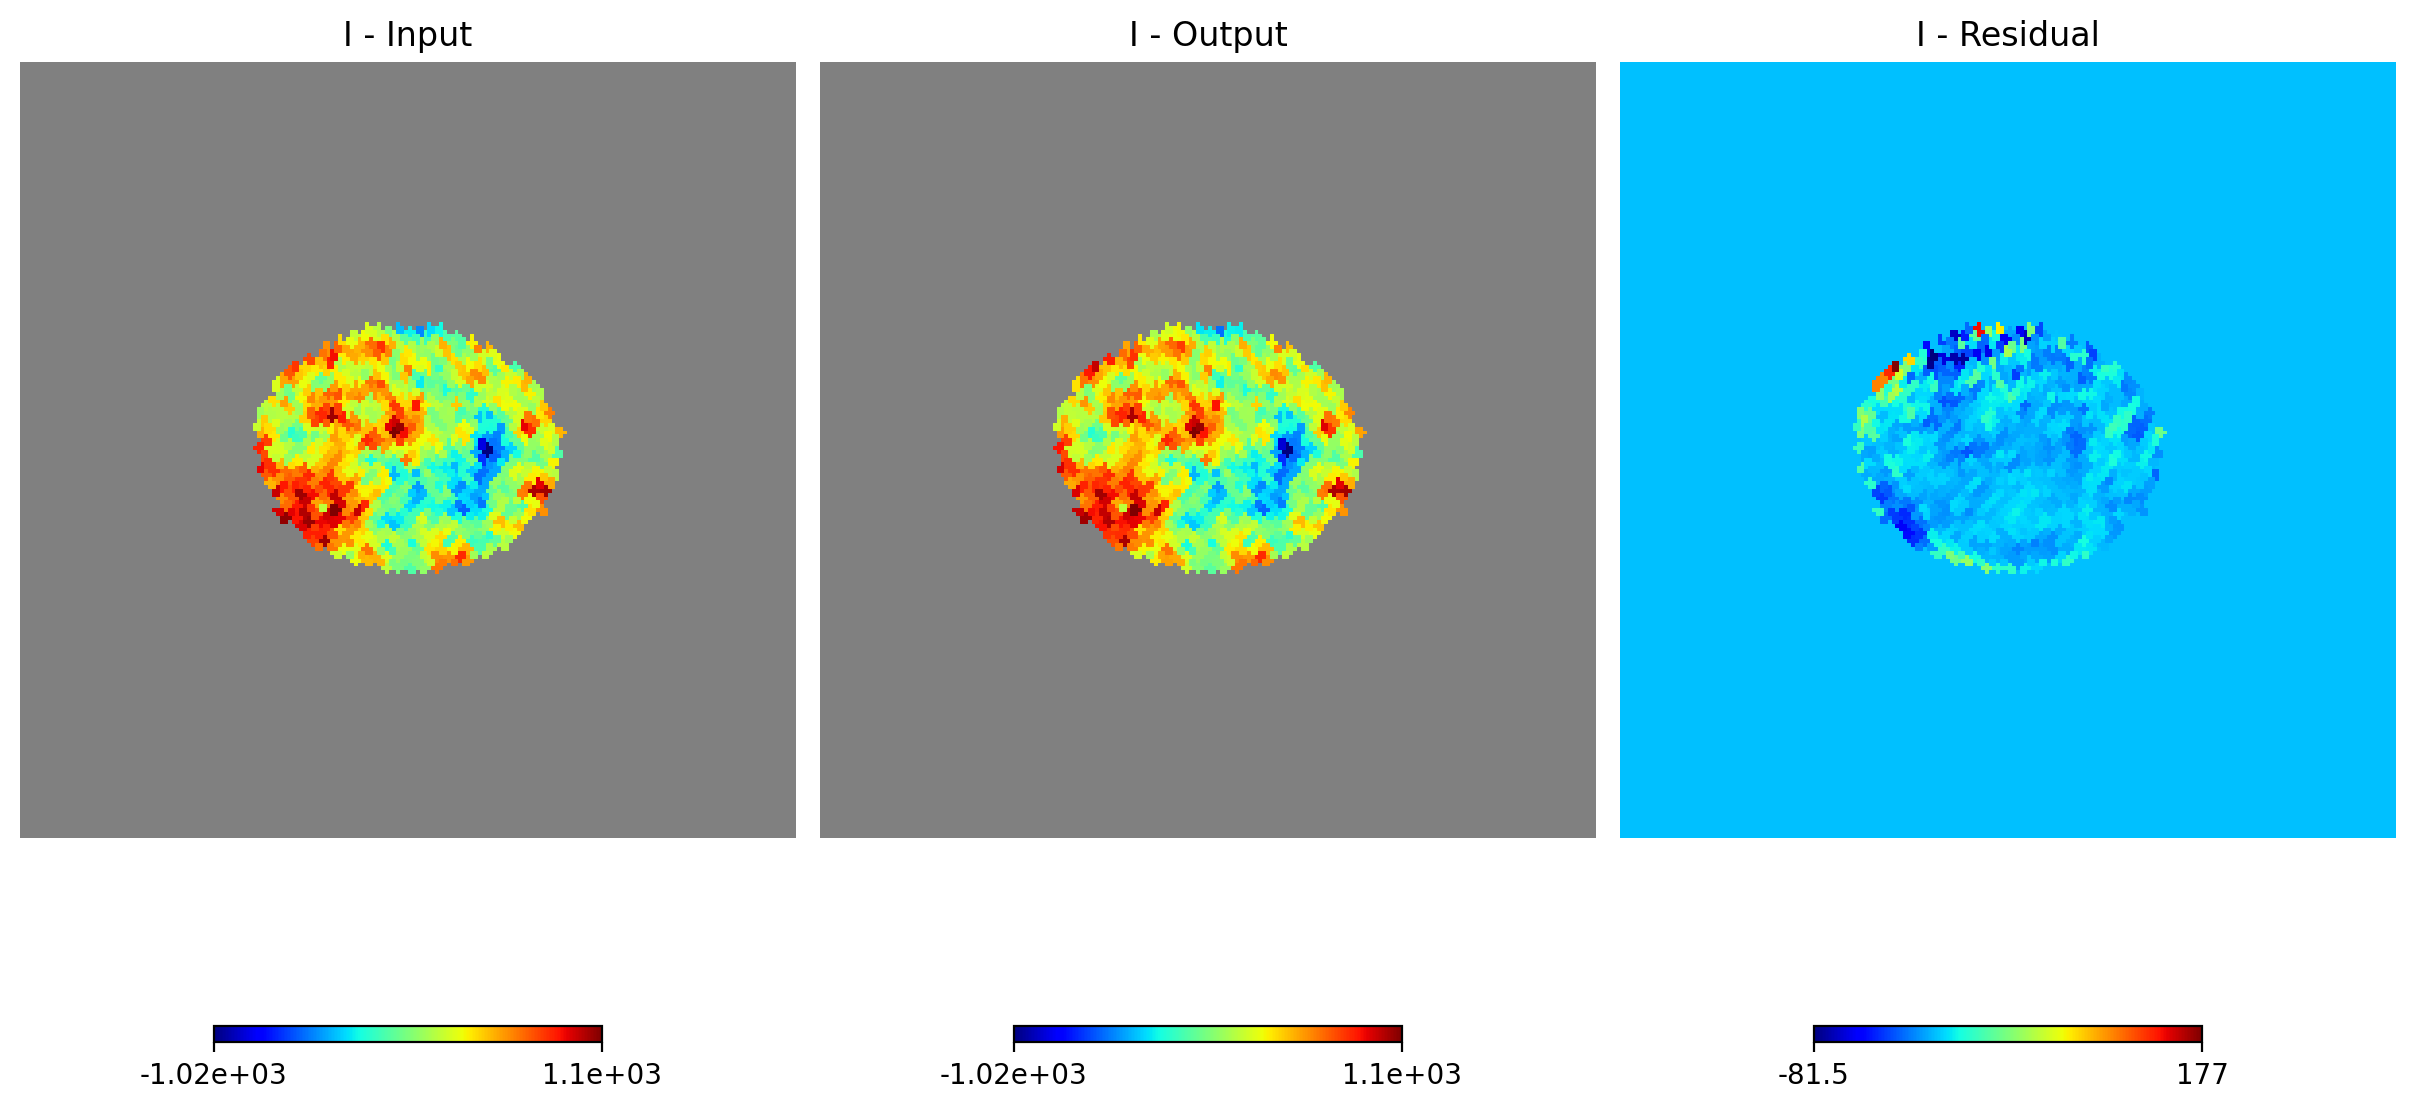

In [44]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
true_maps[:, ~seenpix, :] = hp.UNSEEN
maps_rec_[:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(maps_rec_.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk] - true_maps[inu, :, 0],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(maps_rec_.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

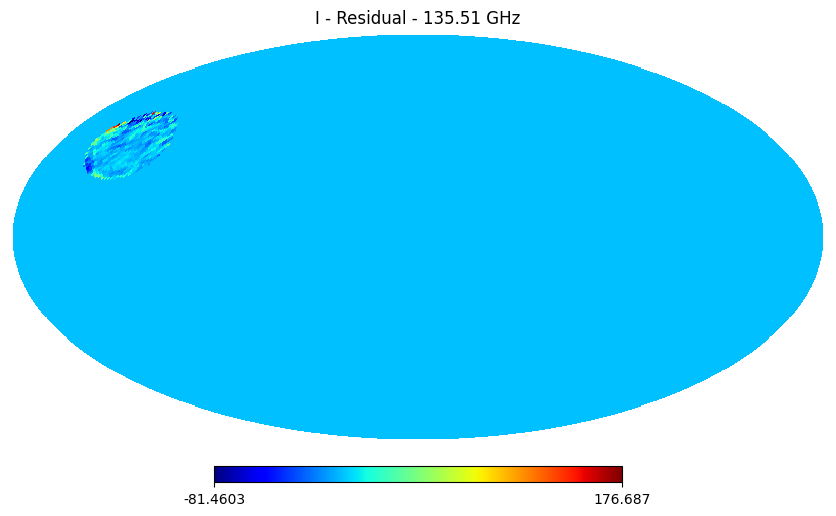

In [45]:
for inu in range(maps_rec_.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.mollview(
        maps_rec_[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        title="{} - Residual - {:.2f} GHz".format(stk[istk], atm.frequencies[inu]),
    )

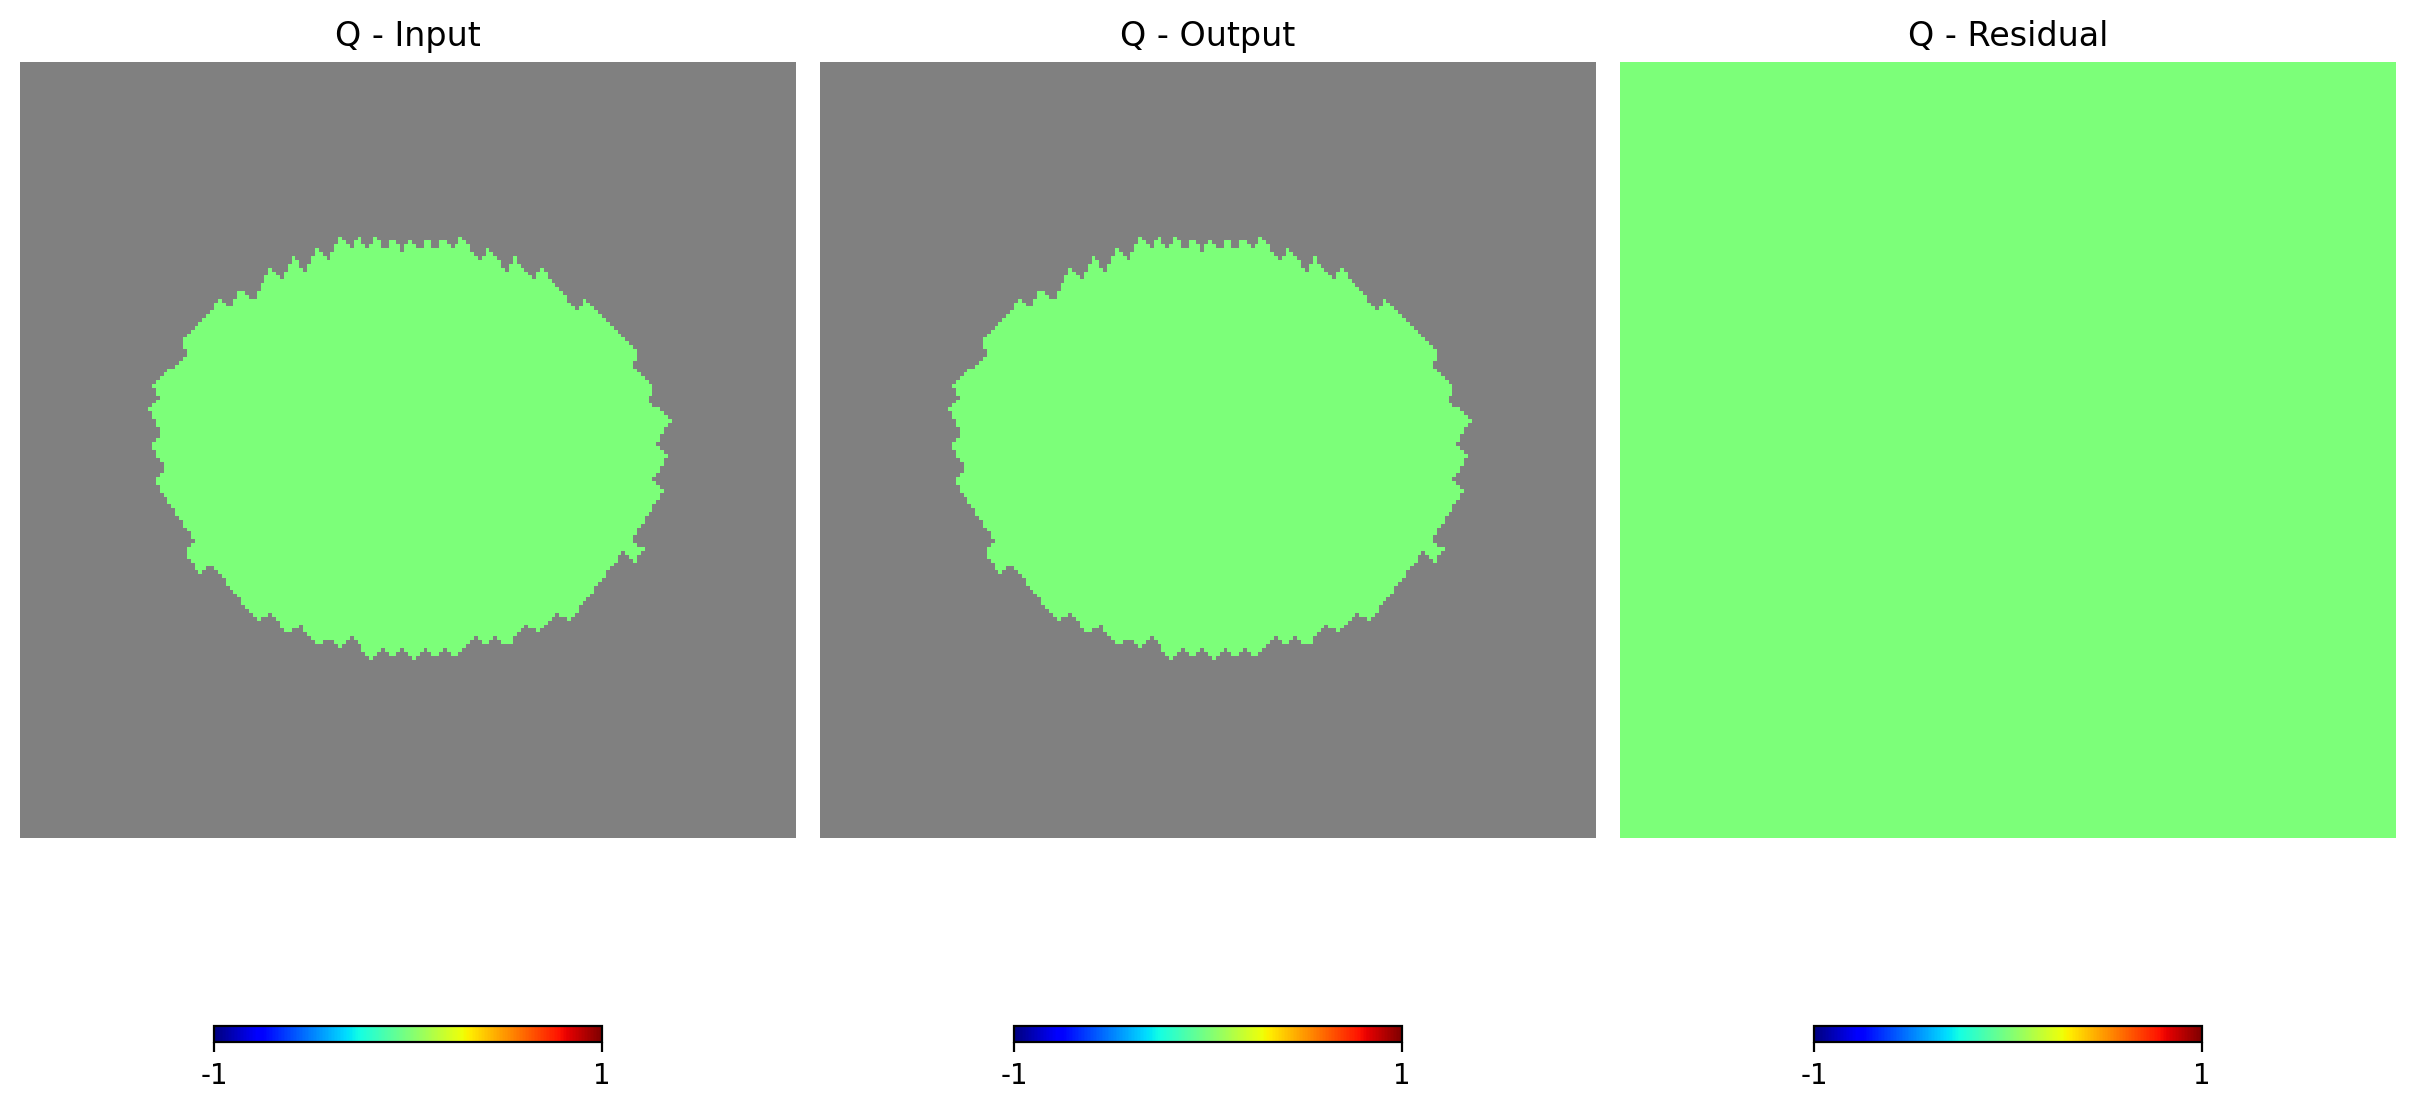

In [46]:
plt.figure(figsize=(12, 12), dpi=200)

k = 1

istk = 1
n_sig = 2

for inu in range(maps_rec_.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=15,
        sub=(maps_rec_.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=15,
        sub=(maps_rec_.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec_[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=15,
        sub=(maps_rec_.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

# Wind Reconstruction

=== 1. Residual sanity (wind=[0,0]) ===
  tod       : mean=4.013e-17  std=4.810e-17
  tod_sim0  : mean=4.737e-17  std=5.198e-17
  residual  : mean=-7.235e-18  std=2.173e-17
  res.std / tod.std = 0.452

=== 2. Chi2 sanity ===
  chi2           = 1.9383e+08
  chi2 / N_data  = 1.9539e+03  (expect ~0.5 if noise-matched)
  sigma2_eff     = 1.2171e+00  (chi2_min / ndf — normalisation factor)
  invN(res) : mean=-5.910e+19  std=1.633e+20

=== 3. Delta-chi2 scan along wy (centred on best-fit) ===


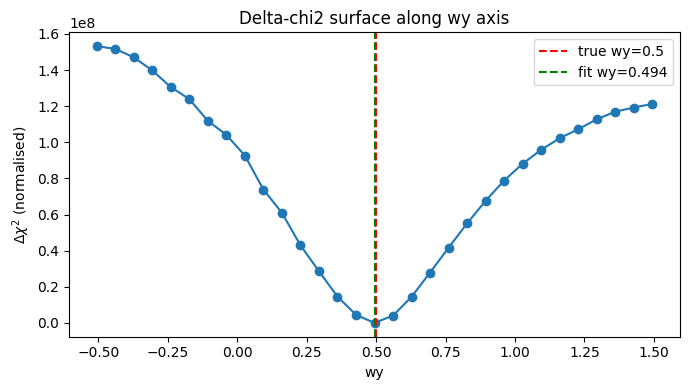

  wy at grid minimum : 0.494

=== 3. Delta-chi2 scan along wx (centred on best-fit) ===


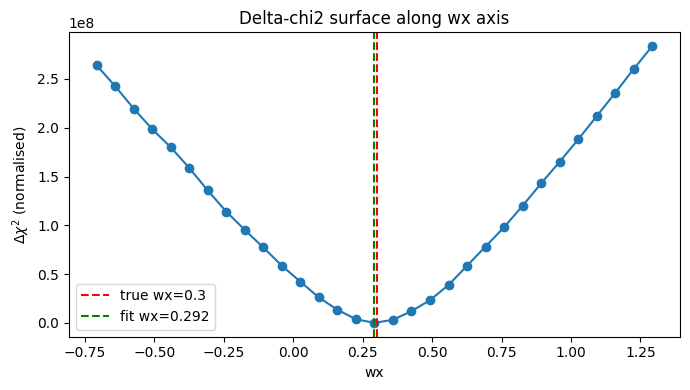

  wx at grid minimum : 0.292

=== 4. Finite-difference gradient vs eps at x=[0,0] ===
  chi2(0,0) = 1.9383e+08  →  scale = 1.9383e+08

  wy component:
         eps       grad (unscaled)         grad (scaled)
     1.0e-01           -1.7544e+08           -9.0514e-01
     5.0e-02           -1.7505e+08           -9.0315e-01
     1.0e-02           -1.7474e+08           -9.0155e-01
     1.0e-03           -1.7468e+08           -9.0119e-01
     1.0e-05            0.0000e+00            0.0000e+00
     1.0e-08            0.0000e+00            0.0000e+00

  wx component:
         eps       grad (unscaled)         grad (scaled)
     1.0e-01           -2.2409e+08           -1.1562e+00
     5.0e-02           -2.2451e+08           -1.1583e+00
     1.0e-02           -2.2488e+08           -1.1602e+00
     1.0e-03           -2.2497e+08           -1.1607e+00
     1.0e-05            0.0000e+00            0.0000e+00
     1.0e-08            0.0000e+00            0.0000e+00

  If grad collapses to ~0 for eps

In [47]:
# ============================================================
# WIND-FITTING DIAGNOSTICS
# Run this cell after at least one iteration of the loop so
# that maps_rec and sigma2_eff are available.
# ============================================================

# --- 1. Residual sanity (wind = [0, 0]) ---
wind0_op = get_wind_operator([0, 0])
tod_sim0 = (Pchunk * H_ * wind0_op * Amm)(P(maps_rec))

res0 = tod - tod_sim0
print("=== 1. Residual sanity (wind=[0,0]) ===")
print(f"  tod       : mean={tod.mean():.3e}  std={tod.std():.3e}")
print(f"  tod_sim0  : mean={tod_sim0.mean():.3e}  std={tod_sim0.std():.3e}")
print(f"  residual  : mean={res0.mean():.3e}  std={res0.std():.3e}")
print(f"  res.std / tod.std = {res0.std() / tod.std():.3f}")

# --- 2. Chi2 sanity ---
invN_res0 = invN(res0)
chi2_val = 0.5 * np.dot(res0, invN_res0)
N_data = tod.size
ndf = N_data - 2
print()
print("=== 2. Chi2 sanity ===")
print(f"  chi2           = {chi2_val:.4e}")
print(f"  chi2 / N_data  = {chi2_val / N_data:.4e}  (expect ~0.5 if noise-matched)")
print(f"  sigma2_eff     = {sigma2_eff:.4e}  (chi2_min / ndf — normalisation factor)")
print(f"  invN(res) : mean={invN_res0.mean():.3e}  std={invN_res0.std():.3e}")

# --- 3. 1-D Delta-chi2 scans centred on best-fit wind ---
wind_best = np.asarray(wind_rec, dtype=float)
chi2_norm_min = get_chi2_norm(wind_best, tod, sigma2_eff)

print()
print("=== 3. Delta-chi2 scan along wy (centred on best-fit) ===")
wy_grid = np.linspace(wind_best[1] - 1.0, wind_best[1] + 1.0, 31)
dchi2_wy = np.array([get_chi2_norm([wind_best[0], wy], tod, sigma2_eff) - chi2_norm_min
                     for wy in wy_grid])

plt.figure(figsize=(7, 4))
plt.plot(wy_grid, dchi2_wy, "o-")
plt.axvline(params["wind_cst"][1], color="r", ls="--", label=f"true wy={params['wind_cst'][1]}")
plt.axvline(wind_best[1], color="g", ls="--", label=f"fit wy={wind_best[1]:.3f}")
# plt.axhline(1.00, color="orange", ls=":", label=r"$\Delta\chi^2=1.00$ (68.3% profile)")
# plt.axhline(2.30, color="purple", ls=":", label=r"$\Delta\chi^2=2.30$ (68.3% joint)")
plt.xlabel("wy"); plt.ylabel(r"$\Delta\chi^2$ (normalised)")
plt.title("Delta-chi2 surface along wy axis")
plt.legend(); plt.tight_layout(); plt.show()
print(f"  wy at grid minimum : {wy_grid[np.argmin(dchi2_wy)]:.3f}")

print()
print("=== 3. Delta-chi2 scan along wx (centred on best-fit) ===")
wx_grid = np.linspace(wind_best[0] - 1.0, wind_best[0] + 1.0, 31)
dchi2_wx = np.array([get_chi2_norm([wx, wind_best[1]], tod, sigma2_eff) - chi2_norm_min
                     for wx in wx_grid])

plt.figure(figsize=(7, 4))
plt.plot(wx_grid, dchi2_wx, "o-")
plt.axvline(params["wind_cst"][0], color="r", ls="--", label=f"true wx={params['wind_cst'][0]}")
plt.axvline(wind_best[0], color="g", ls="--", label=f"fit wx={wind_best[0]:.3f}")
# plt.axhline(1.00, color="orange", ls=":", label=r"$\Delta\chi^2=1.00$ (68.3% profile)")
# plt.axhline(2.30, color="purple", ls=":", label=r"$\Delta\chi^2=2.30$ (68.3% joint)")
plt.xlabel("wx"); plt.ylabel(r"$\Delta\chi^2$ (normalised)")
plt.title("Delta-chi2 surface along wx axis")
plt.legend(); plt.tight_layout(); plt.show()
print(f"  wx at grid minimum : {wx_grid[np.argmin(dchi2_wx)]:.3f}")

# --- 4. Gradient vs eps --- (kept for numerical diagnostics)
print()
print("=== 4. Finite-difference gradient vs eps at x=[0,0] ===")
x_test = np.array([0.0, 0.0])
chi2_0_test = get_chi2(x_test, tod)
scale_test = np.max([chi2_0_test, 1.0])
print(f"  chi2(0,0) = {chi2_0_test:.4e}  →  scale = {scale_test:.4e}")

for comp, pairs in [("wy", [(0, eps_d) for eps_d in [0.1, 0.05, 0.01, 1e-3, 1e-5, 1e-8]]),
                    ("wx", [(eps_d, 0) for eps_d in [0.1, 0.05, 0.01, 1e-3, 1e-5, 1e-8]])]:
    print()
    print(f"  {comp} component:")
    print(f"  {'eps':>10s}  {'grad (unscaled)':>20s}  {'grad (scaled)':>20s}")
    for eps_d in [0.1, 0.05, 0.01, 1e-3, 1e-5, 1e-8]:
        if comp == "wy":
            cp = get_chi2([0, eps_d], tod); cm = get_chi2([0, -eps_d], tod)
        else:
            cp = get_chi2([eps_d, 0], tod); cm = get_chi2([-eps_d, 0], tod)
        g_raw = (cp - cm) / (2 * eps_d)
        print(f"  {eps_d:10.1e}  {g_raw:20.4e}  {g_raw/scale_test:20.4e}")

print()
print("  If grad collapses to ~0 for eps < ~1e-5: internal eps ≈ 1.5e-8 cannot")
print("  detect the gradient → jac must be provided explicitly.")


In [ ]:
# ============================================================
# WIND ERROR BAR ESTIMATION  (PDG statistics, table 40.2)
# Requires sigma2_eff (from fit_wind) and maps_rec to be set.
#
# PDG table 40.2 — Delta chi2 thresholds for normalised chi2:
#   1 parameter (profile)  68.3%: 1.00   90%: 2.71   95.4%: 4.00
#   2 parameters (joint)   68.3%: 2.30   90%: 4.61   95.4%: 6.17
# ============================================================
from scipy.optimize import brentq


def wind_profile_errors(wind_best, tod, sigma2_eff, delta=1.00, bracket=2.0):
    """
    Asymmetric 1-sigma errors on each wind component via profile chi2.
    Fixes one component at wind_best[j] and scans component i until
    Delta chi2_norm = delta (default 1.00 = 68.3% for 1 parameter).
    """
    wind_best = np.asarray(wind_best, dtype=float)
    chi2_norm_min = get_chi2_norm(wind_best, tod, sigma2_eff)
    errors = []
    names = ["wx", "wy"]
    for i in range(2):
        def f_up(dx, i=i):
            x = wind_best.copy(); x[i] += dx
            return get_chi2_norm(x, tod, sigma2_eff) - chi2_norm_min - delta
        def f_dn(dx, i=i):
            x = wind_best.copy(); x[i] -= dx
            return get_chi2_norm(x, tod, sigma2_eff) - chi2_norm_min - delta
        try:
            err_up = brentq(f_up, 0, bracket, xtol=1e-4)
        except ValueError:
            err_up = float("nan")
            print(f"  Warning: upper bracket for {names[i]} not found "
                  f"(f(0)={f_up(0):.3e}, f({bracket})={f_up(bracket):.3e})")
        try:
            err_dn = brentq(f_dn, 0, bracket, xtol=1e-4)
        except ValueError:
            err_dn = float("nan")
            print(f"  Warning: lower bracket for {names[i]} not found "
                  f"(f(0)={f_dn(0):.3e}, f({bracket})={f_dn(bracket):.3e})")
        errors.append((-err_dn, +err_up))
        print(f"  {names[i]} = {wind_best[i]:.4f}  +{err_up:.4f} / -{err_dn:.4f}  "
              f"(delta_chi2={delta:.2f}, 68.3% profile CL)")
    return errors  # [(wx_lo, wx_hi), (wy_lo, wy_hi)]


def wind_hessian_errors(wind_best, tod, sigma2_eff, eps=1e-2):
    """
    Symmetric 1-sigma errors from the 2x2 Hessian of chi2_norm at the minimum.
    Uses 6 chi2 evaluations. Valid when chi2_norm is nearly parabolic near x_best.
    """
    x = np.asarray(wind_best, dtype=float)
    H = np.zeros((2, 2))
    for i in range(2):
        for j in range(i, 2):
            xpp = x.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i, j] = H[j, i] = (
                get_chi2_norm(xpp, tod, sigma2_eff)
                - get_chi2_norm(xpm, tod, sigma2_eff)
                - get_chi2_norm(xmp, tod, sigma2_eff)
                + get_chi2_norm(xmm, tod, sigma2_eff)
            ) / (4 * eps ** 2)
    C = np.linalg.inv(H)
    sigmas = np.sqrt(np.diag(C))
    print(f"  wx = {x[0]:.4f} ± {sigmas[0]:.4f}  |  wy = {x[1]:.4f} ± {sigmas[1]:.4f}")
    print(f"  correlation  rho = {C[0, 1] / (sigmas[0] * sigmas[1]):.3f}")
    return sigmas


def chi2_2d_contour(wind_best, tod, sigma2_eff, n_grid=30, half_range=None):
    """2D Delta-chi2 map with PDG joint confidence contours.
    If half_range is None, auto-scales to show the 68.3% contour clearly.
    """
    wind_best = np.asarray(wind_best, dtype=float)
    chi2_norm_min = get_chi2_norm(wind_best, tod, sigma2_eff)

    # Coarse scan to measure chi2 curvature and set grid scale automatically
    if half_range is None:
        probe = 0.5
        Z_probe = np.array([
            get_chi2_norm([wind_best[0] + probe, wind_best[1]], tod, sigma2_eff),
            get_chi2_norm([wind_best[0] - probe, wind_best[1]], tod, sigma2_eff),
            get_chi2_norm([wind_best[0], wind_best[1] + probe], tod, sigma2_eff),
            get_chi2_norm([wind_best[0], wind_best[1] - probe], tod, sigma2_eff),
        ]) - chi2_norm_min
        Z_probe_max = Z_probe.max()
        # Scale so that the 68.3% contour (Delta=2.30) spans ~30% of the grid
        half_range = probe * np.sqrt(2.30 / np.max([Z_probe_max, 1e-30])) * 3.0
        print(f"  Auto half_range = {half_range:.4f}  (probe Delta chi2_norm at ±{probe} = {Z_probe_max:.3e})")

    wx_arr = np.linspace(wind_best[0] - half_range, wind_best[0] + half_range, n_grid)
    wy_arr = np.linspace(wind_best[1] - half_range, wind_best[1] + half_range, n_grid)
    Z = np.array([[get_chi2_norm([wx, wy], tod, sigma2_eff) - chi2_norm_min
                   for wx in wx_arr] for wy in wy_arr])

    Z_max = Z.max()
    print(f"  Delta chi2_norm range over grid: [0, {Z_max:.3e}]  (PDG 68.3% threshold = 2.30)")
    if Z_max < 2.30:
        estimated = half_range * np.sqrt(2.30 / np.max([Z_max, 1e-30]))
        print(f"  68.3% contour not reached — try half_range ≈ {estimated:.4f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    # extend="both" colours the full grid even when values exceed the top level
    cs = ax.contourf(wx_arr, wy_arr, Z, levels=[0, 1.15, 2.30, 4.61],
                     cmap="RdYlBu_r", extend="both")
    plt.colorbar(cs, ax=ax, label=r"$\Delta\chi^2$")
    # PDG contour lines in black so they are always visible
    for level, ls, lbl in [(2.30, "--", "68.3% joint"), (4.61, ":", "90% joint")]:
        if Z_max > level:
            ax.contour(wx_arr, wy_arr, Z, levels=[level], colors="k",
                       linewidths=1.5, linestyles=ls, label=lbl)
    ax.axvline(params["wind_cst"][0], color="r", ls="--", label=f"true wx={params['wind_cst'][0]}")
    ax.axhline(params["wind_cst"][1], color="b", ls="--", label=f"true wy={params['wind_cst'][1]}")
    ax.scatter(*wind_best, c="k", marker="x", s=120, zorder=5,
               label=f"fit ({wind_best[0]:.3f}, {wind_best[1]:.3f})")
    ax.set_xlabel("wx"); ax.set_ylabel("wy")
    ax.set_title(r"$\Delta\chi^2$ — dashed: $\Delta=2.30$ (68.3%), dotted: $\Delta=4.61$ (90%)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
    return Z, wx_arr, wy_arr
 

# --- Run all three ---
wind_best = np.asarray(wind_rec, dtype=float)

print("=== Error bars: profile chi2 (PDG table 40.2, 1-param, delta=1.00) ===")
errors_profile = wind_profile_errors(wind_best, tod, sigma2_eff)

print()
print("=== Error bars: Hessian (parabolic approx, cross-check) ===")
errors_hessian = wind_hessian_errors(wind_best, tod, sigma2_eff)

print()
print("=== 2D Delta-chi2 confidence contour ===")
Z_map, wx_arr, wy_arr = chi2_2d_contour(wind_best, tod, sigma2_eff)


=== Error bars: profile chi2 (PDG table 40.2, 1-param, delta=1.00) ===
  wx = 0.2923  +0.0039 / -0.0000  (delta_chi2=1.00, 68.3% profile CL)
  wy = 0.4941  +0.0038 / -0.0000  (delta_chi2=1.00, 68.3% profile CL)

=== Error bars: Hessian (parabolic approx, cross-check) ===
  wx = 0.2923 ± 0.0000  |  wy = 0.4941 ± 0.0000
  correlation  rho = -0.014

=== 2D Delta-chi2 confidence contour ===
  Auto half_range = 0.0002  (probe Delta chi2_norm at ±0.5 = 1.087e+08)
